In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph
from typing import Literal
import requests
import dotenv
import json
import ast
import re

/home/gaurav/Desktop/Avaneesh Work/Programming Assignemnt/Country Information AI Agent/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
from prompt import intent_detection_llm_prompt, humanized_response_llm_prompt
from state import State

In [3]:
dotenv.load_dotenv()

True

In [4]:
# Helper Functions

def get_keys(data, prefix=""):
    keys = []
    
    if isinstance(data, dict):
        for key, value in data.items():
            full_key = f"{prefix}.{key}" if prefix else key
            keys.append(full_key)
            keys.extend(get_keys(value, full_key))
    
    elif isinstance(data, list):
        for index, item in enumerate(data):
            full_key = f"{prefix}[{index}]"
            keys.extend(get_keys(item, full_key))
    
    return keys

def parse_llm_json(raw: str):
    """
    Robust parser for LLM JSON outputs.
    - Tries direct json.loads
    - If fails, tries ast.literal_eval for Python-like dicts
    - If still fails, tries to extract JSON block via regex
    - Cleans common LLM JSON issues (trailing commas, stray text)
    """
    if raw is None:
        raise ValueError("LLM returned None")

    raw = raw.strip()

    # Try direct JSON load
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass

    # Try parsing as Python literal (e.g., single-quoted dict)
    try:
        return ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        pass

    # Attempt to extract JSON substring
    match = re.search(r'\{.*\}', raw, re.DOTALL)
    if match:
        json_str = match.group()

        # Fix common issues
        json_str = re.sub(r',\s*}', '}', json_str)
        json_str = re.sub(r',\s*]', ']', json_str)

        try:
            return json.loads(json_str)
        except json.JSONDecodeError:
            try:
                return ast.literal_eval(json_str)
            except (ValueError, SyntaxError):
                pass

    raise ValueError(f"Unable to parse JSON from LLM output:\n{raw}")

In [5]:
# user asks question
# question goes to intent llm to get the country name and the keys
# if the keys that llm gave were in the keys of response of that country then well and good otherwise we run the node with that country name and tell llm the real available keys for that country and give it those keys and get the response back.
# for well and good we get the final data and give it to an llm and ask it to get the 

In [6]:
def start_node(state):
    """This node will initialize the state with values"""
    print("Starting the workflow...")
    print("--" * 20)
    print("Current Node: start_node")
    question = "What is the currency for India?"
    llm_model = "gpt-4o-mini"

    return {
        "llm_model_name": llm_model,
        "question_from_user": question
    }

In [7]:
def intent_detection(state):
    print("--" * 20)
    print("Current Node: intent_detection")
    if state["all_keys_from_response"] != []:
        prompt = intent_detection_llm_prompt(question_from_user = state["question_from_user"],available_keys = state["all_keys_from_response"])
    else:
        prompt = intent_detection_llm_prompt(question_from_user = state["question_from_user"])
    llm = ChatOpenAI(model = state["llm_model_name"])
    response = llm.invoke(prompt)
    response = parse_llm_json(response.content)
    return {"intent_llm_response":response}

In [8]:
def call_api_condition(state) -> Literal["api_calling", "end_node"]:
    print("--" * 20)
    print("Current Node: call_api_condition")
    if state["intent_llm_response"]["keys"] != None and state["intent_llm_response"]["country"].lower() != "invalid":
        return "api_calling"
    else:
        return "end_node"

In [9]:
def api_calling(state):
    print("--" * 20)
    print("Current Node: api_calling")
    api_url = "https://restcountries.com/v3.1/name/{country_name}"
    try:
        api_url = api_url.format(country_name = state["intent_llm_response"]["country"])
        response = requests.get(api_url)
        response = json.loads(response.content)
        if "message" in response:
            return {"api_call_response":response,"api_call_success_code":response["status"]}
    except:
        return {"api_call_response":{},"api_call_success_code":500}
    
    return {"api_call_response":response,"api_call_success_code":200}

In [10]:
def fetch_relevant_data_condition(state) -> Literal["fetch_relevant_columns", "intent_detection", "end_node"]:
    print("--" * 20)
    print("Current Node: fetch_relevant_data_condition")
    if state["api_call_success_code"] == 200:
        return "fetch_relevant_columns"
    if state["api_call_success_code"] == 500:
        return "end_node"
    if state["api_call_success_code"]  == 404:
        return "intent_detection"

In [11]:
def fetch_relevant_columns(state):
    print("--" * 20)
    print("Current Node: fetch_relevant_columns")
    relevant_data = {}
    valid_keys_by_llm = False

    keys = state.get("intent_llm_response", {}).get("keys")
    response = state.get("api_call_response")

    if not response:
        return {"relevant_data": None}

    for index, element in enumerate(response):
        relevant_data[index] = {}
        value = element

        for key in keys:
            try:
                for part in key.split("."):
                    value = value[part]

                relevant_data[index][key] = value
                valid_keys_by_llm = True

            except:
                relevant_data[index][key] = None
        
        relevant_data[index]["name.common"] = element.get("name", {}).get("common")
        relevant_data[index]["name.official"] = element.get("name", {}).get("official")

    return {"relevant_data": relevant_data, "valid_keys_by_llm": valid_keys_by_llm}

In [12]:
def humanized_response_condition(state) -> Literal["humanized_response", "fetch_relevant_keys_from_response", "end_node"]:
    print("--" * 20)
    print("Current Node: humanized_response_condition")
    if state["valid_keys_by_llm"]:
        return "humanized_response"
    
    if state["passed_relevent_keys_to_intent"]:
        return "end_node"
    return "fetch_relevant_keys_from_response"

In [13]:
def fetch_relevant_keys_from_response(state):
    print("--" * 20)
    print("Current Node: fetch_relevant_keys_from_response")
    keys = get_keys(state["api_call_response"])
    return {"all_keys_from_response": keys, "passed_relevent_keys_to_intent": True}

In [14]:
def humanized_response(state):
    print("--" * 20)
    print("Current Node: humanized_response")
    prompt = humanized_response_llm_prompt(question=state["question_from_user"],relevant_data=state["relevant_data"])
    llm = ChatOpenAI(model = state["llm_model_name"])
    response = llm.invoke(prompt)
    response = parse_llm_json(response.content)
    return {"humanized_answer":response}

In [15]:
def end_node(state):
    print("--" * 20)
    print("Current Node: end_node")
    return state["humanized_answer"]

In [16]:
workflow = StateGraph(State)

workflow.add_node("start",start_node)
workflow.add_node("intent_detection",intent_detection)
workflow.add_node("api_calling",api_calling)
workflow.add_node("fetch_relevant_columns",fetch_relevant_columns)
workflow.add_node("fetch_relevant_keys_from_response",fetch_relevant_keys_from_response)
workflow.add_node("humanized_response",humanized_response)
workflow.add_node("end_node",end_node)

workflow.set_entry_point("start")

workflow.add_edge("start","intent_detection")
workflow.add_conditional_edges("intent_detection",call_api_condition)
workflow.add_conditional_edges("api_calling",fetch_relevant_data_condition)
workflow.add_conditional_edges("fetch_relevant_columns",humanized_response_condition)
workflow.add_edge("fetch_relevant_keys_from_response","intent_detection")
workflow.add_edge("humanized_response","end_node")

app = workflow.compile()

In [17]:
initial_state = {
    "llm_model_name" : "",
    "question_from_user" : "",
    "intent_llm_response":{},
    "api_call_response" : {},
    "api_call_success_code":0,
    "relevant_data":{},
    "valid_keys_by_llm": False,
    "all_keys_from_response": [],
    "humanized_answer": {},
    "passed_relevent_keys_to_intent": False
}

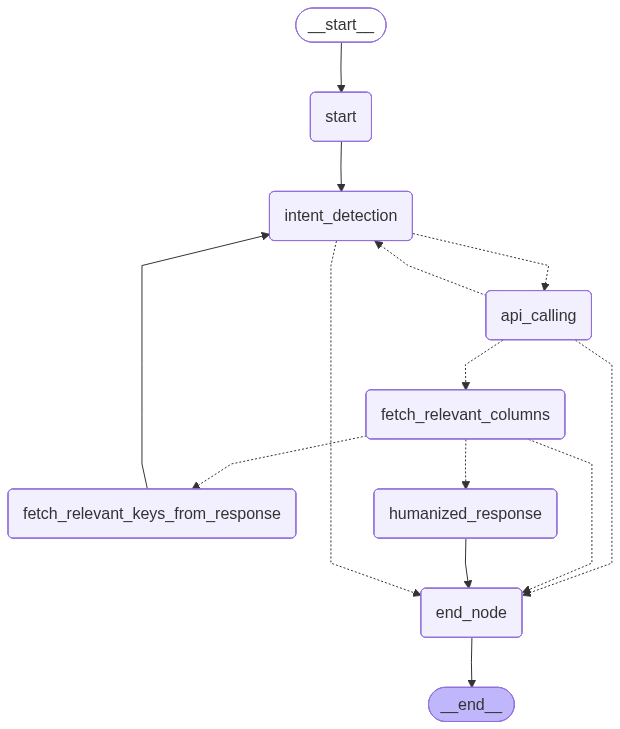

In [18]:
from IPython.display import Image, display

png = app.get_graph().draw_mermaid_png()
display(Image(png))

In [19]:
final_state = app.invoke(initial_state)

Starting the workflow...
----------------------------------------
Current Node: start_node
----------------------------------------
Current Node: intent_detection
----------------------------------------
Current Node: call_api_condition
----------------------------------------
Current Node: api_calling
----------------------------------------
Current Node: fetch_relevant_data_condition
----------------------------------------
Current Node: fetch_relevant_columns
----------------------------------------
Current Node: humanized_response_condition
----------------------------------------
Current Node: humanized_response
----------------------------------------
Current Node: end_node
